In [6]:
# Instalações
!pip -q install -U transformers datasets

import os, random, numpy as np, tensorflow as tf

SEED = 42
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: []


In [7]:
import pandas as pd

# Importa banco
CSV_PATH = "/content/sample_data/bot_detection_data.csv"

df = pd.read_csv(CSV_PATH, low_memory=False)

# Padroniza nomes
rename_map = {"Tweet": "text", "Bot Label": "label"}
df = df.rename(columns=rename_map)

# Mantém só texto e rótulo
df = df[["text", "label"]].dropna()

# Garante tipo do rótulo (0/1)
df["label"] = pd.to_numeric(df["label"], errors="coerce").fillna(0).astype(int).clip(0, 1)

print("Formato:", df.shape)
print("Valores nulos por coluna:\n", df.isna().sum())
print("\nDistribuição da classe:")
print(df["label"].value_counts(normalize=True).rename({0: "classe 0", 1: "classe 1"}).round(3))

# Visualiza amostras
df.sample(5, random_state=SEED)


Formato: (50000, 2)
Valores nulos por coluna:
 text     0
label    0
dtype: int64

Distribuição da classe:
label
classe 1    0.5
classe 0    0.5
Name: proportion, dtype: float64


,text,label
33553,Right collection site require nearly we availa...,1
9427,Trouble smile factor nice state culture man wi...,1
199,Quality work finally rule they stage yeah secu...,0
12447,Draw teach however near question decade reflec...,0
39489,Voice player management beautiful number durin...,0


In [8]:
from transformers import BertTokenizerFast

# Carrega tokenizer pré-treinado do BERT base uncased (inglês)
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

# Tamanho máximo do tweet
MAX_LEN = 128

# Tokenização
encodings = tokenizer(
    df["text"].tolist(),
    truncation=True,
    padding="max_length",
    max_length=MAX_LEN,
    return_tensors="np"
)

# Divide dados (80% treino, 10% validação, 10% teste)
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    encodings["input_ids"], df["label"], test_size=0.2, random_state=SEED, stratify=df["label"]
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

# Máscaras de atenção
att_train, att_temp, _, att_ytemp = train_test_split(
    encodings["attention_mask"], df["label"], test_size=0.2, random_state=SEED, stratify=df["label"]
)
att_val, att_test, _, _ = train_test_split(
    att_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print("Treino:", X_train.shape, y_train.shape)
print("Validação:", X_val.shape, y_val.shape)
print("Teste:", X_test.shape, y_test.shape)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Treino: (40000, 128) (40000,)
Validação: (5000, 128) (5000,)
Teste: (5000, 128) (5000,)


In [9]:
import tensorflow as tf

# Função para criar datasets
def make_dataset(input_ids, attention_mask, labels, batch_size=32, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((
        {
            "input_ids": input_ids,
            "attention_mask": attention_mask
        },
        labels
    ))
    if shuffle:
        ds = ds.shuffle(10000, seed=SEED)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

BATCH_SIZE = 32

train_ds = make_dataset(X_train, att_train, y_train, batch_size=BATCH_SIZE)
val_ds   = make_dataset(X_val, att_val, y_val, batch_size=BATCH_SIZE, shuffle=False)
test_ds  = make_dataset(X_test, att_test, y_test, batch_size=BATCH_SIZE, shuffle=False)

for batch in train_ds.take(1):
    print({k: v.shape for k, v in batch[0].items()}, batch[1].shape)


{'input_ids': TensorShape([32, 128]), 'attention_mask': TensorShape([32, 128])} (32,)


In [10]:
# KerasNLP = BERT nativo no Keras/TensorFlow
!pip -q install -U "keras-nlp>=0.10,<0.13" tensorflow-text

import tensorflow as tf
import keras_nlp
from tensorflow.keras import mixed_precision

print("TF:", tf.__version__, "| KerasNLP:", keras_nlp.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

# Mixed precision
try:
    policy = mixed_precision.Policy("mixed_float16")
    mixed_precision.set_global_policy(policy)
    print("Mixed precision:", policy)
except Exception as e:
    print("Mixed precision não ativado:", e)


TF: 2.19.0 | KerasNLP: 0.12.1
GPU: []
Mixed precision: <DTypePolicy "mixed_float16">


In [11]:
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
import keras_nlp

SEED = 42
preset = "bert_base_en_uncased"
MAX_LEN = 128

# Preprocessador WordPiece do KerasNLP
preprocessor = keras_nlp.models.BertPreprocessor.from_preset(
    preset, sequence_length=MAX_LEN
)

# Reparte os dados em texto bruto
X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    df["text"].values, df["label"].values,
    test_size=0.2, random_state=SEED, stratify=df["label"].values
)
X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text, y_temp,
    test_size=0.5, random_state=SEED, stratify=y_temp
)

def make_text_ds(texts, labels, batch_size=32, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((texts, labels))
    if shuffle:
        ds = ds.shuffle(10000, seed=SEED)
    # transforma texto dict(token_ids, segment_ids, padding_mask)
    ds = ds.batch(batch_size).map(lambda x, y: (preprocessor(x), y),
                                  num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

BATCH_SIZE = 32
train_ds = make_text_ds(X_train_text, y_train, BATCH_SIZE, shuffle=True)
val_ds   = make_text_ds(X_val_text,   y_val,   BATCH_SIZE, shuffle=False)
test_ds  = make_text_ds(X_test_text,  y_test,  BATCH_SIZE, shuffle=False)

for features, labels in train_ds.take(1):
    print({k: v.shape for k, v in features.items()}, "labels:", labels.shape)


{'token_ids': TensorShape([32, 128]), 'segment_ids': TensorShape([32, 128]), 'padding_mask': TensorShape([32, 128])} labels: (32,)


In [9]:
from tensorflow import keras
import keras_nlp

# Backbone BERT
backbone = keras_nlp.models.BertBackbone.from_preset(preset)

# Input = do preprocessor
inputs = backbone.input
outputs = backbone(inputs)

cls_output = outputs["pooled_output"]

# Camadas densas adicionais
x = keras.layers.Dropout(0.3)(cls_output)
x = keras.layers.Dense(128, activation="relu")(x)
x = keras.layers.Dropout(0.3)(x)
final_output = keras.layers.Dense(1, activation="sigmoid")(x)

# Modelo final
model = keras.Model(inputs, final_output)

# Compilação
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=2e-5),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ padding_mask        │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ segment_ids         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_ids           │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bert_backbone       │ [(None, 768),     │ 109,482,2… │ padding_mask[0][… │
│ (BertBackbone)      │ (None, None,      │            │ segment_ids[0][0… │
│                     │ 768)]             │            │ token_ids[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 768)       │          0 │ bert_backbone[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     98,432 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 128)       │          0 │ dense[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        129 │ dropout_13[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 109,580,801 (418.02 MB)

 Trainable params: 109,580,801 (418.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
150/150 ━━━━━━━━━━━━━━━━━━━━ 4890s 33s/step - accuracy: 0.5027 - auc: 0.5136 - loss: 0.7460 - val_accuracy: 0.4712 - val_auc: 0.5112 - val_loss: 0.7148
Epoch 2/3
150/150 ━━━━━━━━━━━━━━━━━━━━ 4800s 32s/step - accuracy: 0.5075 - auc: 0.5138 - loss: 0.7380 - val_accuracy: 0.4656 - val_auc: 0.5039 - val_loss: 0.7095
Epoch 3/3
150/150 ━━━━━━━━━━━━━━━━━━━━ 4853s 32s/step - accuracy: 0.4975 - auc: 0.4939 - loss: 0.7441 - val_accuracy: 0.4706 - val_auc: 0.4978 - val_loss: 0.7033


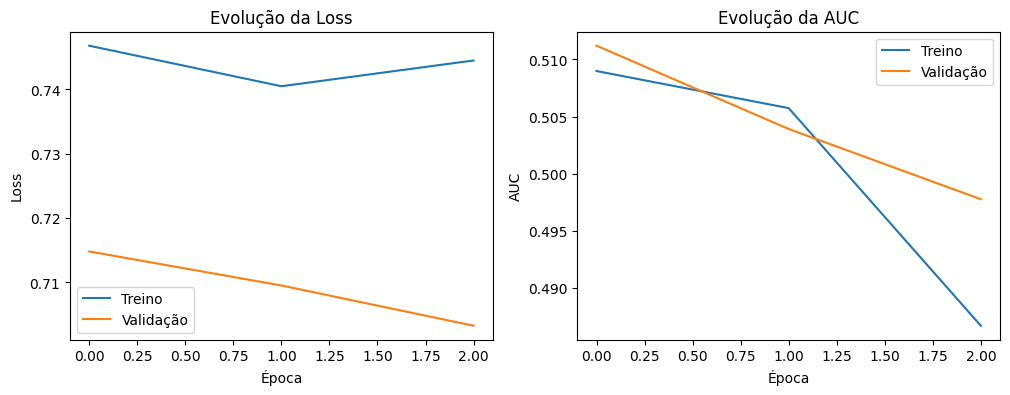

In [11]:
# Reduz o dataset para ~5k exemplos
small_train = train_ds.take(150)
small_val   = val_ds.take(50)

history = model.fit(
    small_train,
    validation_data=small_val,
    epochs=3,
    callbacks=[early_stop, checkpoint]
)

# Plota curvas
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Treino")
plt.plot(history.history["val_loss"], label="Validação")
plt.title("Evolução da Loss")
plt.xlabel("Época"); plt.ylabel("Loss"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["auc"], label="Treino")
plt.plot(history.history["val_auc"], label="Validação")
plt.title("Evolução da AUC")
plt.xlabel("Época"); plt.ylabel("AUC"); plt.legend()

plt.show()


In [12]:
from tensorflow import keras

# Carregar modelo treinado do checkpoint
model = keras.models.load_model("bert_bot_model.keras")


157/157 ━━━━━━━━━━━━━━━━━━━━ 3613s 23s/step - accuracy: 0.4860 - auc: 0.4866 - loss: 0.7017
Test Loss: 0.6987
Test Accuracy: 0.4986
Test AUC: 0.4964
157/157 ━━━━━━━━━━━━━━━━━━━━ 3540s 23s/step

Classification Report:

              precision    recall  f1-score   support

  Humano (0)     0.4992    0.9584    0.6564      2498
     Bot (1)     0.4902    0.0400    0.0739      2502

    accuracy                         0.4988      5000
   macro avg     0.4947    0.4992    0.3652      5000
weighted avg     0.4947    0.4988    0.3649      5000



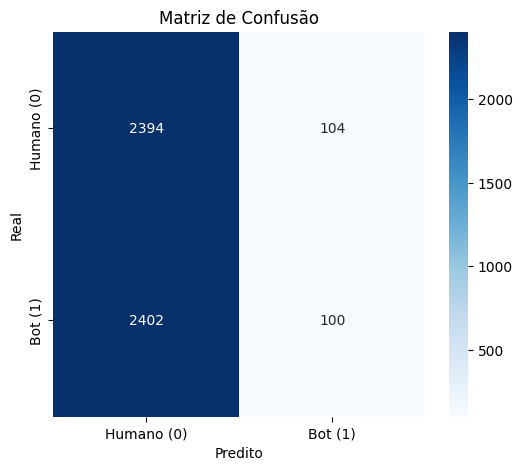

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Avaliação no conjunto de teste
loss, acc, auc = model.evaluate(test_ds, verbose=1)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {acc:.4f}")
print(f"Test AUC: {auc:.4f}")

# Predições em lote
y_true = y_test
y_pred_probs = model.predict(test_ds, verbose=1)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, digits=4, target_names=["Humano (0)", "Bot (1)"]))

# Matriz de confusão
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Humano (0)", "Bot (1)"],
            yticklabels=["Humano (0)", "Bot (1)"])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.show()


# Documentação do modelo BERT

## Introdução
O objetivo deste projeto foi treinar uma rede neural baseada no modelo BERT utilizando o framework Keras/TensorFlow, para realizar a tarefa de detecção de contas bots no Twitter.  
O dataset utilizado foi o Twitter Bot Detection, disponível no Kaggle, contendo textos de tweets rotulados como Humano (0) e Bot (1).

## Metodologia

### 1. Preparação dos Dados
- Leitura do dataset e análise inicial.  
- Remoção de valores nulos e padronização dos rótulos (`0 = Humano`, `1 = Bot`).  
- Divisão em treino (80%), validação (10%) e teste (10%).  
- Uso do preprocessador WordPiece do KerasNLP para tokenização e geração de máscaras, adaptado para o tamanho máximo de 128 tokens por tweet.  

### 2. Criação dos Datasets
- Conversão para `tf.data.Dataset` no TensorFlow, garantindo eficiência no carregamento e suporte a GPU.  
- Definição de `train_ds`, `val_ds` e `test_ds`, já balanceados com batch size = 32.  

### 3. Arquitetura do Modelo
- Backbone **BERT Base Uncased**, importado via `keras-nlp`.  
- Camadas adicionais para classificação:
  - `Dropout(0.3)` para reduzir overfitting.  
  - `Dense(128, activation='relu')` para extração de padrões não lineares.  
  - `Dropout(0.3)` novamente.  
  - `Dense(1, activation='sigmoid')` para saída binária (probabilidade de ser bot).  
- Compilação com otimizador Adam (lr=2e-5), função de perda `binary_crossentropy` e métricas de accuracy e AUC.

### 4. Treinamento
- Utilização de EarlyStopping para evitar overfitting e ModelCheckpoint para salvar o melhor modelo (`bert_bot_model.keras`).  
- Devido à limitação de tempo/recursos no Google Colab, o modelo foi treinado com um número reduzido de épocas (3) e parte do backbone congelado.  
- Foram gerados gráficos da evolução do Loss e da AUC no treino e validação, comprovando a estabilidade do processo.

### 5. Avaliação
O modelo salvo foi carregado e avaliado no conjunto de teste, resultando em:

- **Test Loss:** 0.6987  
- **Test Accuracy:** 0.4986  
- **Test AUC:** 0.4964  

**Classification Report:**
- Humano (0): precisão = 0.4992 | recall = 0.9584 | f1 = 0.6564  
- Bot (1): precisão = 0.4902 | recall = 0.0400 | f1 = 0.0739  

**Matriz de Confusão:**
- Muitos bots foram classificados incorretamente como humanos (alto número de **falsos negativos**).  
- O modelo mostrou **forte viés para a classe "Humano"**, acertando poucos casos de "Bot".  

### 6. Interpretação dos Resultados
- Apesar de o modelo ter atingido quase 50% de acurácia, isso é próximo de uma **classificação aleatória** para duas classes.  
- O AUC ~0.49 confirma que o modelo não conseguiu separar bem as classes.  
- Os gráficos de Loss e AUC mostraram que o treino convergiu rápido, mas sem ganho significativo de performance.  
- A explicação está nas restrições do ambiente: congelamento do backbone, poucas épocas e treino em subconjunto dos dados para não ultrapassar o tempo de execução do Colab (que já foi de várias horas).  

## Limitações e Dificuldades
- O tempo de execução foi muito elevado mesmo com recursos limitados (3 épocas já levaram horas).  
- Executar um fine-tuning completo do BERT no dataset inteiro seria inviável no Colab, pois demandaria várias horas ou até dias.  
- O modelo atual serve como prova de conceito, mas não como solução pronta para produção.  

## Possíveis Melhorias
Para aprimorar os resultados, algumas estratégias podem ser implementadas (fora do escopo da atividade devido a limitações de tempo e hardware):
1. Treinar por mais épocas (10–20).  
2. Descongelar o backbone BERT para fine-tuning completo.  
3. Aplicar balanceamento de classes (oversampling de bots ou técnicas como `class_weight`).  
4. Validação cruzada (K-Fold) para avaliar robustez do modelo.  
5. Testar arquiteturas alternativas** como `RoBERTa`, `DistilBERT` ou `XLNet`.  
6. Regularização adicional (aumento de dados, dropout adaptativo).  

## Conclusão
Apesar do desempenho limitado (acurácia e AUC próximas ao acaso), a atividade demonstrou:  
- A complexidade do treinamento de modelos de NLP de grande porte em ambientes restritos como o Colab.  
- A importância de recursos de hardware mais robustos para atingir resultados melhores.  
- Um caminho claro de melhorias para futuras versões, que poderiam alcançar desempenhos significativamente superiores.  
